In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('bengaluru_house_prices.csv')

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.shape

(13320, 9)

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64

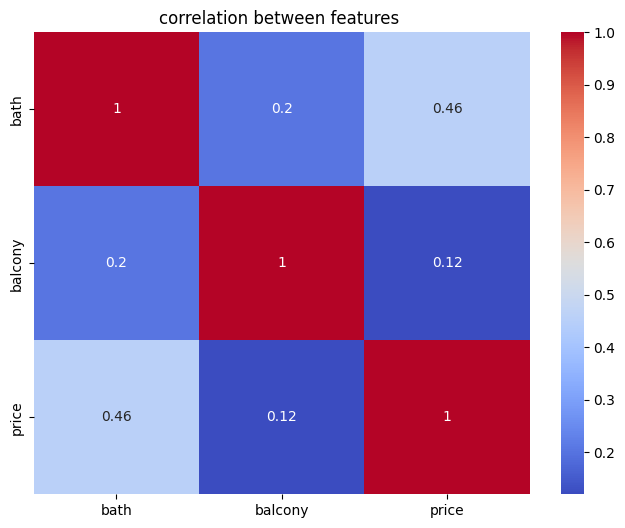

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
corr =df.corr
plt.figure(figsize=(8,6))
sns.heatmap(corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('correlation between features ')
plt.show()

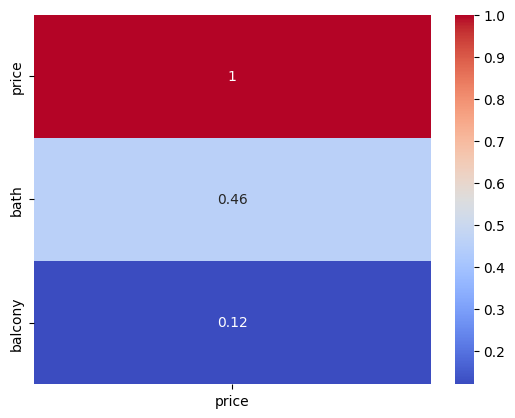

In [10]:
corr =df.corr(numeric_only=True)
plt.Figure(figsize=(8,6))
sns.heatmap(corr[['price']].sort_values(by='price',ascending=False),annot=True,cmap='coolwarm')
plt.show()

In [11]:
for col in df.columns:
    if df[col].isnull().sum()>=1:
        if df[col].dtype=='object':
            df[col].fillna(df[col].mode()[0],inplace=True)
        else:
             df[col].fillna(df[col].mean(),inplace=True)        

C:\Users\USER\AppData\Local\Temp\ipykernel_15664\4018266379.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_15664\4018266379.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [12]:
df.isnull().sum().sort_values(ascending=False)

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [ ]:
df = pd.get_dummies(df, drop_first=True)


TypeError: DataFrame.drop() takes from 1 to 2 positional arguments but 3 were given

In [14]:
df.columns
# corr =df.corr()
# plt.Figure(figsize=(8,6))
# sns.heatmap(corr[['price']].sort_values(by='price',ascending=False),annot=True,cmap='coolwarm')
# plt.show()

Index(['bath', 'balcony', 'price', 'area_type_Carpet  Area',
       'area_type_Plot  Area', 'area_type_Super built-up  Area',
       'availability_14-Nov', 'availability_15-Aug', 'availability_15-Dec',
       'availability_15-Jun',
       ...
       'total_sqft_990', 'total_sqft_991', 'total_sqft_992', 'total_sqft_993',
       'total_sqft_994', 'total_sqft_995', 'total_sqft_996', 'total_sqft_997',
       'total_sqft_998', 'total_sqft_999'],
      dtype='object', length=6223)

In [15]:
# corr =df.corr
# plt.figure(figsize=(8,6))
# sns.heatmap(corr(numeric_only=True),annot=True,cmap='coolwarm')
# plt.title('correlation between features ')
# plt.show()

In [16]:
import numpy as np
X=df.drop(columns=['price'])
y = np.log1p(df['price'])


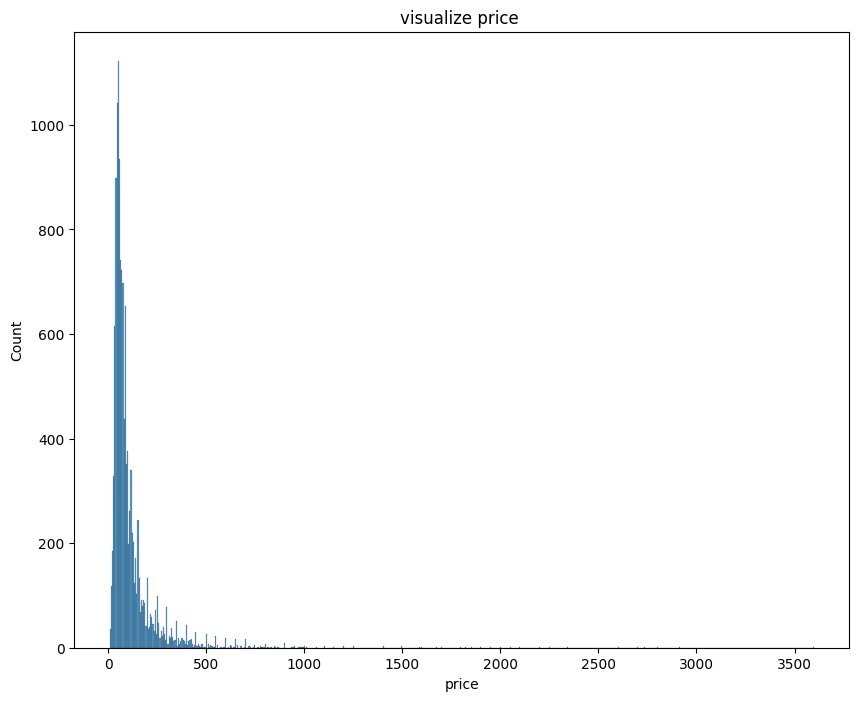

In [17]:
plt.figure(figsize=(10,8))
sns.histplot(x=df['price'])
plt.title("visualize price ")
plt.show()

<Axes: xlabel='price', ylabel='Density'>

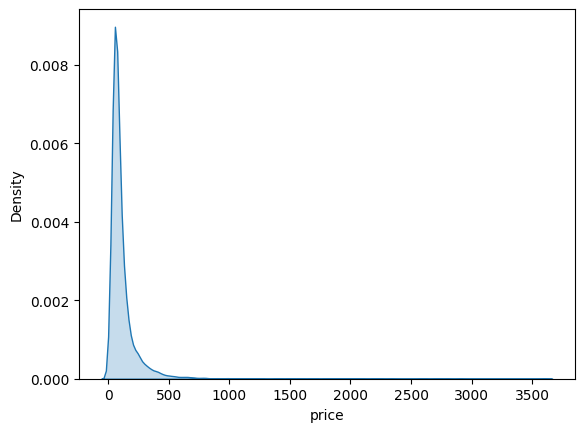

In [18]:
sns.kdeplot(df['price'],fill=True)


In [19]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_scaled=scale.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train, y_test=train_test_split(X_scaled,y,test_size=0.2)

In [21]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor
models={
    'SVM':SVR(),
    'knn':KNeighborsRegressor(),
    'linear regression':LinearRegression(),
    'ID3':DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'XG_boost':XGBRFRegressor()
}

In [22]:
from sklearn.model_selection import cross_val_score
scores=[]
for model_name,model_per in models.items():
    r2 = cross_val_score(model_per, X_scaled, y, cv=5, scoring='r2').mean()
    scores.append({'model_name': model_name, 'R2': r2})

result=pd.DataFrame(scores)
result


KeyboardInterrupt: 